<a href="https://colab.research.google.com/github/ak-ayanat/deep-learning-final-project/blob/master/notebooks/01_eda_flickr8k.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opendatasets
import opendatasets as od

# Download the dataset. When the cell starts, it will ask for your Kaggle username and Kaggle key.
od.download("https://www.kaggle.com/datasets/adityajn105/flickr8k")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: ayanatkanat
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/adityajn105/flickr8k


100%|██████████| 1.04G/1.04G [00:08<00:00, 124MB/s]


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import random
from collections import Counter
import string


# File paths (opendatasets will create a flickr8k folder)
text_path = "flickr8k/captions.txt"
images_path = "flickr8k/Images/"

# Uploading text descriptions
df = pd.read_csv(text_path)
print(f"Total rows in dataset: {len(df)}")
print(f"Unique images: {df['image'].nunique()}")

# Let's look at the first 5 lines
df.head()

Total rows in dataset: 40455
Unique images: 8091


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


Average caption length: 11.78 words
Maximum caption length: 38 words


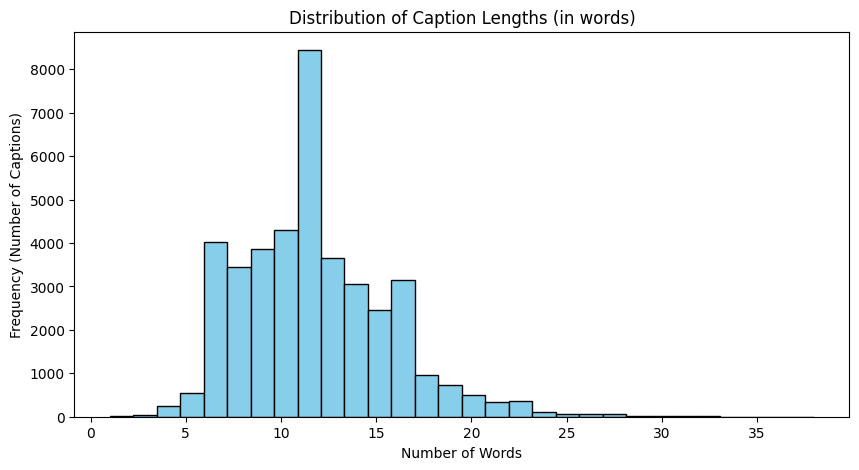

In [4]:
# Calculate the number of words in each caption
df['word_count'] = df['caption'].apply(lambda x: len(str(x).split()))

# Print text length statistics
print(f"Average caption length: {df['word_count'].mean():.2f} words")
print(f"Maximum caption length: {df['word_count'].max()} words")

# Plot the distribution of caption lengths
plt.figure(figsize=(10, 5))
plt.hist(df['word_count'], bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Caption Lengths (in words)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency (Number of Captions)")
plt.show()

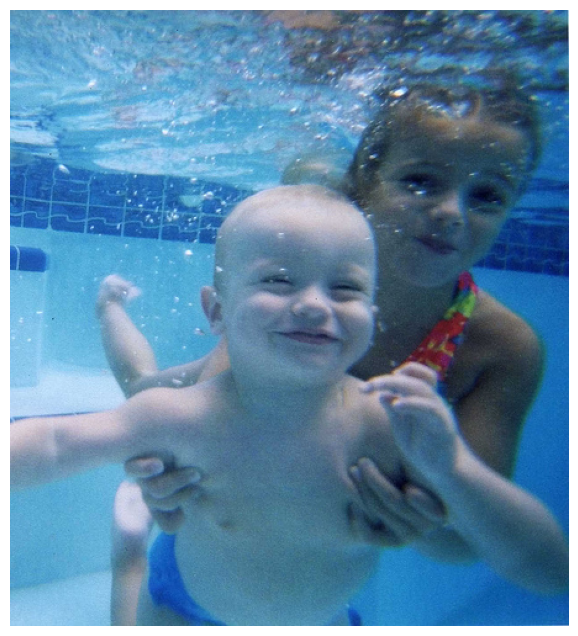

Captions for this image:
1. A baby being held by a small girl , swimming underwater in a blue pool .
2. A child supports a toddler underwater in a pool .
3. A small girl and a toddler swimming underwater in a pool .
4. A young girl and baby boy are swimming underwater in a pool .
5. Two children smile underwater


In [5]:
# Select a random image from the unique images list
random_image = random.choice(df['image'].unique())

# Get all 5 captions corresponding to this specific image
captions = df[df['image'] == random_image]['caption'].values

# Load and display the image
img = mpimg.imread(os.path.join(images_path, random_image))
plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis('off') # Hide axes for better visual presentation
plt.show()

# Print the 5 captions
print("Captions for this image:")
for i, cap in enumerate(captions, 1):
    print(f"{i}. {cap}")

Total vocabulary size (unique words): 8828


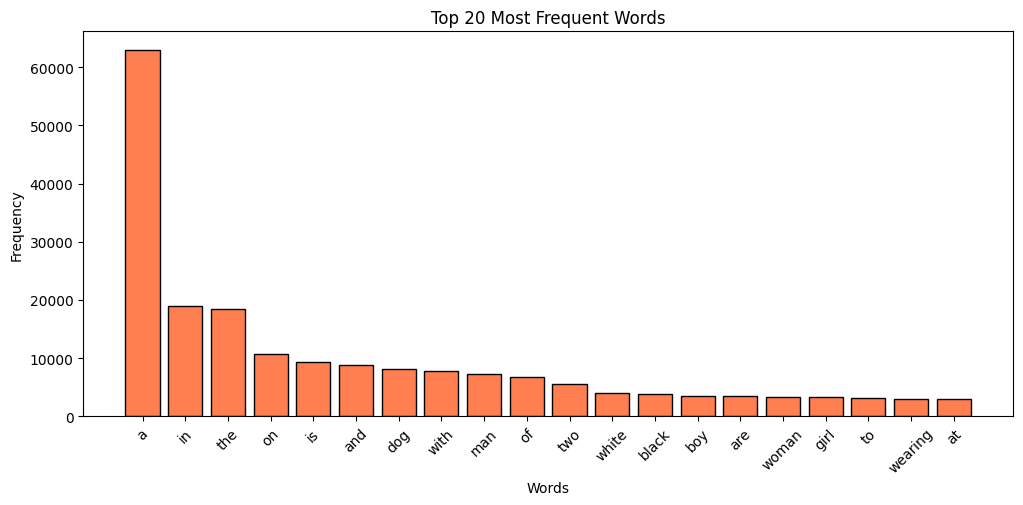

In [7]:
# Helper function to clean text (lowercase and remove punctuation)
def clean_text(text):
    text = str(text).lower()
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

# Apply cleaning to all captions
df['cleaned_caption'] = df['caption'].apply(clean_text)

# Collect all words into a single list
all_words = ' '.join(df['cleaned_caption'].tolist()).split()

# Count the frequencies
word_counts = Counter(all_words)

print(f"Total vocabulary size (unique words): {len(word_counts)}")

# Get the top 20 most common words
top_20_words = word_counts.most_common(20)

# Plot the top 20 words
words, counts = zip(*top_20_words)
plt.figure(figsize=(12, 5))
plt.bar(words, counts, color='coral', edgecolor='black')
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()